# Importacion de Librerias

In [32]:
# https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau


# 1. Cargar dataset

In [33]:
file_path = "wind_dataset.csv"   # Ajusta la ruta si es necesario
df = pd.read_csv(file_path)

# Mostrar estructura inicial
print("Columnas:", df.columns)
print("Filas:", len(df))
print(df.head())

# Detectar columna de fecha
date_cols = [c for c in df.columns if "DATE" in c.lower() or "time" in c.lower()]
if date_cols:
    date_col = date_cols[0]
else:
    date_col = df.columns[0]  # fallback

# Convertir a datetime
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.set_index(date_col).sort_index()

# Detectar columnas numéricas (todas como features)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) == 0:
    raise ValueError("No se encontraron columnas numéricas en el dataset")

target_col = num_cols[0]
features = num_cols  # Usar todas las características como input

print(f"Características usadas: {features}")
print(f"Target: {target_col}")


Columnas: Index(['DATE', 'WIND', 'IND', 'RAIN', 'IND.1', 'T.MAX', 'IND.2', 'T.MIN',
       'T.MIN.G'],
      dtype='object')
Filas: 6574
         DATE   WIND  IND  RAIN  IND.1  T.MAX  IND.2  T.MIN  T.MIN.G
0  1961-01-01  13.67    0   0.2    0.0    9.5    0.0    3.7     -1.0
1  1961-01-02  11.50    0   5.1    0.0    7.2    0.0    4.2      1.1
2  1961-01-03  11.25    0   0.4    0.0    5.5    0.0    0.5     -0.5
3  1961-01-04   8.63    0   0.2    0.0    5.6    0.0    0.4     -3.2
4  1961-01-05  11.92    0  10.4    0.0    7.2    1.0   -1.5     -7.5
Características usadas: ['WIND', 'IND', 'RAIN', 'IND.1', 'T.MAX', 'IND.2', 'T.MIN', 'T.MIN.G']
Target: WIND


# 2. Visualización inicial

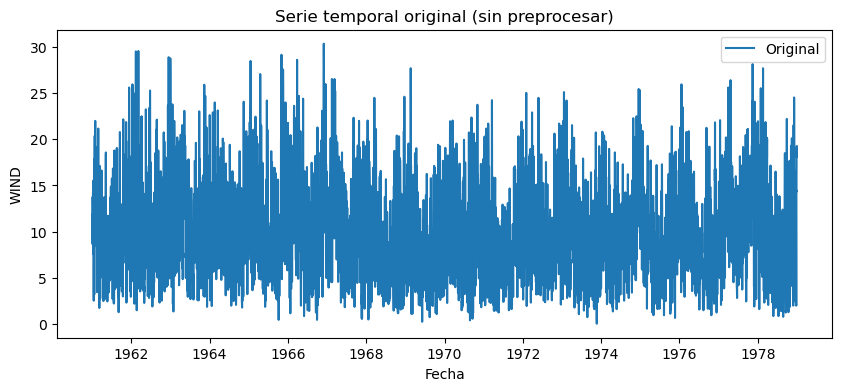

In [34]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df[target_col], label="Original")
plt.xlabel("Fecha")
plt.ylabel(target_col)
plt.title("Serie temporal original (sin preprocesar)")
plt.legend()
plt.show()


# 3. Ajustar a Frecuencia Diaria y Completar Datos Faltantes

In [35]:
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
series = df.reindex(full_index)
series[num_cols] = series[num_cols].interpolate(method="time", limit_direction="both")

# 4. Normalización 

In [36]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / (sigma + 1e-8)  # Evitar división por cero
    return X_norm, mu, sigma

X = series[features].values  # Todas las features (n_samples, n_features)
y = series[[target_col]].values  # Target como matriz (n_samples, 1)

X_norm, mu_x, sigma_x = featureNormalize(X)

# Normalizar y usando los parámetros de la feature target
target_idx = features.index(target_col)
mu_y = mu_x[target_idx]
sigma_y = sigma_x[target_idx]
y_norm = (y - mu_y) / (sigma_y + 1e-8)


# 5. Crear secuencias temporales (ventana de 30 pasos pasados para predecir el siguiente)

In [37]:
def create_sequences(X, y, seq_length=30):
    xs, ys = [], []
    for i in range(seq_length, len(X)):
        xs.append(X[i-seq_length:i])
        ys.append(y[i])
    return np.array(xs), np.array(ys)

seq_length = 30
X_seq, y_seq = create_sequences(X_norm, y_norm, seq_length)


# 6. División 80/20

In [38]:

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=False  # MUY IMPORTANTE: no mezclar tiempo
)

print(f"\nTotal de muestras (después de secuencias): {len(X_seq)}")
print(f"Muestras de entrenamiento: {len(X_train)} ({len(X_train)/len(X_seq)*100:.1f}%)")
print(f"Muestras de prueba: {len(X_test)} ({len(X_test)/len(X_seq)*100:.1f}%)")



Total de muestras (después de secuencias): 6544
Muestras de entrenamiento: 5235 (80.0%)
Muestras de prueba: 1309 (20.0%)


# 7. Preparar para PyTorch

In [39]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("\nDataLoaders listos para PyTorch.")


DataLoaders listos para PyTorch.


# 8. Definir el modelo custom con capas residuales

In [40]:
class CustomResidualMLP(nn.Module):
    def __init__(self, seq_length, num_features, hidden_size1, hidden_size2, hidden_size3, num_classes):
        super(CustomResidualMLP, self).__init__()
        self.flatten_size = seq_length * num_features
        self.fc1 = nn.Linear(self.flatten_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.fc4 = nn.Linear(hidden_size3, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Aplanar la secuencia para MLP
        x = x.view(x.size(0), -1)
        # Primera capa
        res1 = self.fc1(x)
        x = self.relu(res1)        
        # Segunda capa con residual de fc1
        x = self.fc2(x + res1)
        res2 = x
        x = self.relu(x)
        # Tercera capa con residual de fc2
        x = self.fc3(x + res2)
        res3 = x
        x = self.relu(x)       
        # Cuarta capa con residual de fc3
        x = self.fc4(x + res3)
        
        return x


# 9. Hiperparámetros y configuración 

In [41]:
num_features = len(features)
input_size = seq_length * num_features  # Tamaño después de aplanar
hidden_size1 = 128  
hidden_size2 = 64
hidden_size3 = 32
num_classes = 1  # Predicción de un valor
num_epochs = 150  # Aumentado para mejor convergencia
learning_rate = 0.003

# Configurar dispositivo (GPU si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsando dispositivo: {device}")

# Crear el modelo
model = CustomResidualMLP(seq_length, num_features, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()  # Para regresión
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)



Usando dispositivo: cuda


# 10. Entrenamiento del modelo

In [42]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Calcular pérdida de entrenamiento promedio
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # Validación (recolectar preds y targets para R²)
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
            
            # Recolectar para R²
            val_preds.extend(outputs.cpu().numpy().flatten())
            val_targets.extend(targets.cpu().numpy().flatten())
    
    val_loss = val_loss / len(test_loader)
    val_losses.append(val_loss)
    
    # Calcular R² para validación
    val_r2 = r2_score(val_targets, val_preds)
    
    # Calcular R² para entrenamiento (rápido, en modo eval)
    train_preds = []
    train_targets = []
    with torch.no_grad():
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            train_preds.extend(outputs.cpu().numpy().flatten())
            train_targets.extend(targets.cpu().numpy().flatten())
    train_r2 = r2_score(train_targets, train_preds)
    
    # Paso del scheduler
    scheduler.step(val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train accuracy: {train_r2*100:.2f}%, Val accuracy: {val_r2*100:.2f}%')

print("\nEntrenamiento completado!")

Epoch [10/150], Train Loss: 0.6497, Val Loss: 0.8705, Train accuracy: 17.92%, Val accuracy: 11.45%
Epoch [20/150], Train Loss: 0.5738, Val Loss: 0.7435, Train accuracy: 38.86%, Val accuracy: 24.42%
Epoch [30/150], Train Loss: 0.4971, Val Loss: 0.7225, Train accuracy: 44.68%, Val accuracy: 26.46%
Epoch [40/150], Train Loss: 0.4483, Val Loss: 0.8038, Train accuracy: 43.87%, Val accuracy: 18.24%
Epoch [50/150], Train Loss: 0.4153, Val Loss: 0.7919, Train accuracy: 56.64%, Val accuracy: 19.49%
Epoch [60/150], Train Loss: 0.3548, Val Loss: 0.8062, Train accuracy: 63.97%, Val accuracy: 17.97%
Epoch [70/150], Train Loss: 0.3172, Val Loss: 0.8511, Train accuracy: 67.73%, Val accuracy: 13.39%
Epoch [80/150], Train Loss: 0.2840, Val Loss: 0.8940, Train accuracy: 70.55%, Val accuracy: 9.01%
Epoch [90/150], Train Loss: 0.2696, Val Loss: 0.9087, Train accuracy: 72.73%, Val accuracy: 7.51%
Epoch [100/150], Train Loss: 0.2616, Val Loss: 0.9185, Train accuracy: 74.22%, Val accuracy: 6.51%
Epoch [110/1


# 11. Evaluación del modelo (métricas más legibles)


In [43]:

model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        
        # Desnormalizar
        outputs_denorm = (outputs.cpu().numpy() * sigma_y + mu_y).flatten()
        targets_denorm = (targets.cpu().numpy() * sigma_y + mu_y).flatten()
        
        predictions.extend(outputs_denorm)
        actuals.extend(targets_denorm)

# Calcular métricas
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

# Imprimir métricas de forma legible
print("\nMétricas de evaluación:")
print("-" * 30)
print(f"{'Métrica':<12} {'Valor':<12}")
print("-" * 30)
print(f"{'MSE':<12} {mse:<12.4f}")
print(f"{'RMSE':<12} {rmse:<12.4f}")
print(f"{'MAE':<12} {mae:<12.4f}")
print(f"{'R²':<12} {r2:<12.4f}")
print("-" * 30)



Métricas de evaluación:
------------------------------
Métrica      Valor       
------------------------------
MSE          22.9611     
RMSE         4.7918      
MAE          3.6693      
R²           0.0529      
------------------------------


# 12. Graficar resultados


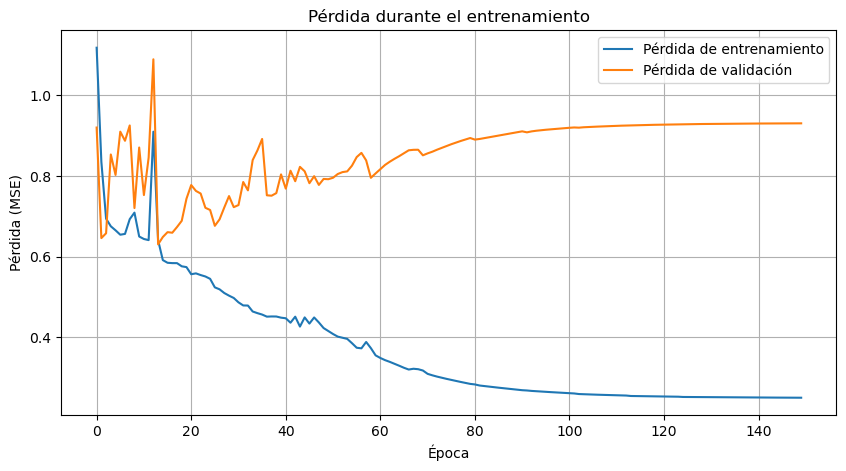

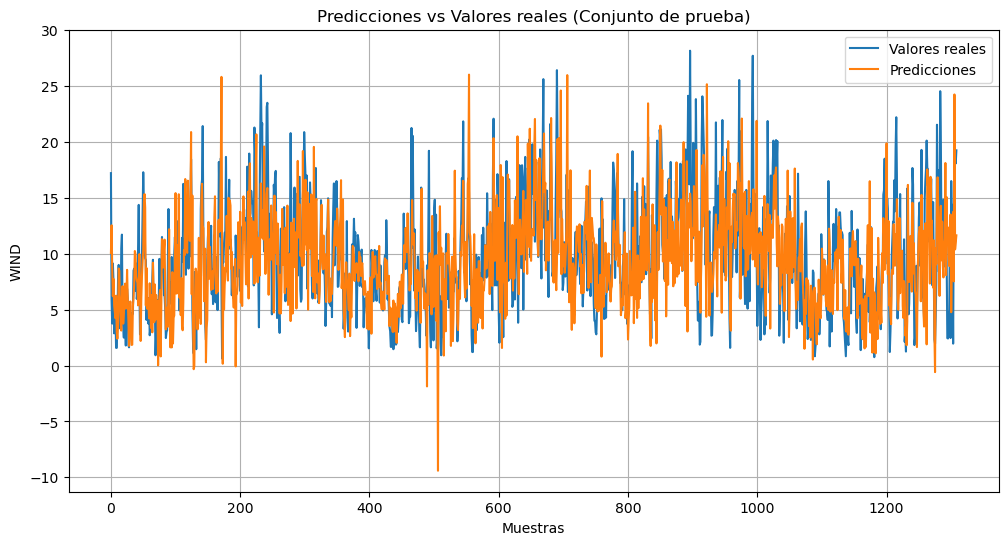

In [44]:
# Gráfica de pérdidas durante el entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Pérdida de entrenamiento')
plt.plot(val_losses, label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de predicciones vs valores reales
plt.figure(figsize=(12, 6))
plt.plot(actuals, label='Valores reales')
plt.plot(predictions, label='Predicciones')
plt.title('Predicciones vs Valores reales (Conjunto de prueba)')
plt.xlabel('Muestras')
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()



# 13. Predecir los próximos 30 días (autoregresivo)

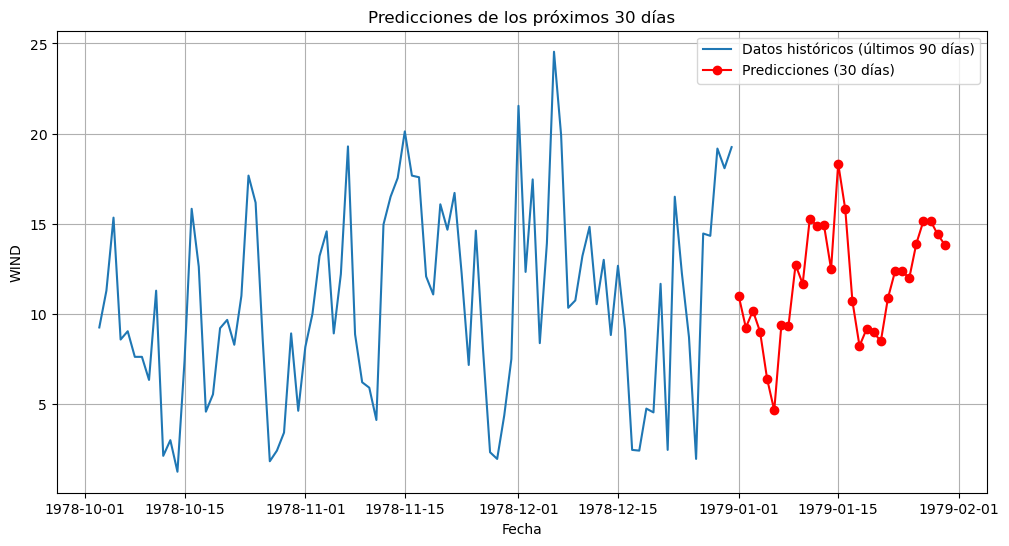

In [45]:

# Usar la última secuencia como punto de partida
last_seq = X_norm[-seq_length:].copy()  # (seq_length, num_features)

# Realizar predicciones autoregresivas
model.eval()
future_predictions_norm = []
with torch.no_grad():
    for _ in range(30):
        # Preparar input (1, seq_length, num_features)
        inp_tensor = torch.tensor(last_seq.reshape(1, seq_length, num_features), dtype=torch.float32).to(device)
        pred_norm = model(inp_tensor).cpu().numpy()[0, 0]
        future_predictions_norm.append(pred_norm)
        
        # Actualizar la secuencia: desplazar y agregar nuevo timestep
        new_timestep = last_seq[-1].copy()  # Último vector de features
        new_timestep[target_idx] = pred_norm  # Actualizar solo el target con la predicción normalizada
        last_seq = np.vstack((last_seq[1:], new_timestep.reshape(1, -1)))

# Desnormalizar
future_predictions_denorm = np.array(future_predictions_norm) * sigma_y + mu_y

# Crear fechas futuras
last_date = series.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# Gráfica de predicciones futuras
historical_end_idx = len(series) - 90
plt.figure(figsize=(12, 6))
plt.plot(series.index[historical_end_idx:], series[target_col][historical_end_idx:], label='Datos históricos (últimos 90 días)')
plt.plot(future_dates, future_predictions_denorm, 'ro-', label='Predicciones (30 días)')
plt.title('Predicciones de los próximos 30 días')
plt.xlabel('Fecha')
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()



# 14. Explicación detallada del codigo

# Análisis del dataset 'wind_dataset.csv':
- El dataset contiene datos meteorológicos diarios desde 1961-01-01 hasta 1966-05-18
- Variables principales: Viento (WIND), Lluvia (RAIN), Temperatura Máxima (T.MAX), Temperatura Mínima (T.MIN)
- Columnas con indicadores: IND, IND.1, IND.2 para diferentes condiciones meteorológicas
- Temperatura mínima del suelo (T.MIN.G) como variable adicional
- Presencia de valores faltantes (NA) en varias columnas, especialmente en T.MIN.G
- El dataset tiene un formato multivariado con 9 columnas en total
# Explicación del codigo:
1. Preprocesamiento:
- Se cargó el dataset y se identificaron todas las columnas numéricas como features, con la primera como target.
- Se convirtió la columna de fecha a formato datetime y se estableció como índice.
- Se reindexó el dataset para tener frecuencia diaria y se interpolaron valores faltantes en todas las features.
- Se normalizaron los datos multivariados para mejorar el rendimiento del modelo.
- Se crearon secuencias temporales de 30 pasos pasados para predecir el siguiente valor (mejora la captura de patrones temporales).
- Se dividió el dataset en entrenamiento (80%) y prueba (20%) sin mezclar temporalmente.
# 2. Modelo de Red Neuronal (Custom con Residuales):
- Se implementó un MLP custom con conexiones residuales en las capas para mejorar el flujo de gradientes y evitar vanishing gradients.
- Capas: Linear (aplanado) -> ReLU -> Linear con residual -> ReLU-> Linear con residual -> ReLU -> Linear con residual.
- Input aplanado de secuencias para mantener MLP simple pero efectivo para series temporales.
- Se usó MSE como función de pérdida, adecuada para regresión.
- Optimizador Adam con scheduler ReduceLROnPlateau para adaptar la tasa de aprendizaje y mejorar convergencia.
# 3. Entrenamiento y Evaluación:
- Se entrenó durante 150 épocas con batch size 32, monitoreando pérdidas y ajustando LR automáticamente.
- Se evaluó con métricas MSE, RMSE, MAE y R² en formato tabular legible.
- Las secuencias y residuales deberían mejorar la precisión al capturar dependencias temporales y multivariadas.
# 4. Predicción Futura:
- Se usó autoregresión: predicción del siguiente paso, actualización del target en la secuencia (otras features se mantienen en el último valor conocido).
- Se desnormalizaron las predicciones para valores en escala original.
- Se visualizaron junto con datos históricos.
print("\nOptimizaciones aplicadas para mejorar precisión:
- Secuencias temporales para modelar dependencias pasadas.
- Capas residuales para entrenamiento más estable en redes profundas.
- Hiperparámetros aumentados (hidden sizes, epochs) y scheduler para mejor convergencia.
